#**Project Title: Social Media Engagement Analytics Using Python**
Dataset Provided:
social_media_engagement_5000.csv


**Task 1 — Data Import & Setup**

In [1]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np


In [3]:
#Step 2: Load dataset from GitHub raw link
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)


In [6]:
# Step 3: Preview the Data

# Display first 5 rows
print(df.head())

# Display dataset info
print(df.info())


   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

**#Check/convert data types**

In [7]:
#Check/convert data types
# Check data types of all columns
print(df.dtypes)

# Or more detailed info
print(df.info())


user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type    

In [8]:
# Convert 'posted_at' column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')


/tmp/ipykernel_632/4204691044.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')


In [9]:
# List of numeric columns
numeric_cols = ['likes', 'comments', 'shares', 'watch_time_sec',
                'impression_count', 'follower_count', 'engagement_rate']

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [10]:
# Convert categorical columns to category dtype
categorical_cols = ['gender', 'country', 'post_type', 'post_category',
                    'device_type', 'sentiment', 'is_verified']

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [11]:
print(df.dtypes)


user_id                      int64
age                        float64
gender                    category
country                   category
post_id                      int64
post_type                 category
post_category             category
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified               category
device_type               category
sentiment                 category
hashtags                    object
engagement_rate            float64
dtype: object


**Convert date columns to datetime**

In [12]:
print(df.columns)


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')


In [13]:
# Convert 'posted_at' column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')


In [14]:
print(df['posted_at'].head())
print(df['posted_at'].dtype)


0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[ns]
datetime64[ns]


**Use NumPy arrays for basic array operations**

In [15]:
import numpy as np

# Example: Likes column
likes_array = df['likes'].values
print(likes_array[:10])  # preview first 10 values


[ 7011. 11750.  4862.  5350. 12682. 12535. 11703.  9611.    nan 14106.]


In [16]:
# Mean, Min, Max
print("Mean likes:", np.mean(likes_array))
print("Min likes:", np.min(likes_array))
print("Max likes:", np.max(likes_array))

# Standard deviation
print("Std Dev likes:", np.std(likes_array))


Mean likes: nan
Min likes: nan
Max likes: nan
Std Dev likes: nan


In [17]:
#Step 3: Element-wise Operations

# Scale likes by factor of 2
likes_scaled = likes_array * 2

# Add 10 to each like count
likes_plus10 = likes_array + 10

print(likes_scaled[:5])
print(likes_plus10[:5])


[14022. 23500.  9724. 10700. 25364.]
[ 7021. 11760.  4872.  5360. 12692.]


In [18]:
#Step 4: Multi-column NumPy Array
# Convert multiple numeric columns into a 2D NumPy array
engagement_array = df[['likes','comments','shares']].values

print("Shape:", engagement_array.shape)
print("First row:", engagement_array[0])


Shape: (5000, 3)
First row: [7011.  354. 1157.]


In [19]:
#Step 5: Slicing & Indexing
# First 5 rows
print(engagement_array[:5])

# Only 'comments' column (index 1)
print(engagement_array[:,1][:5])

# Likes + Shares for first 5 posts
print(engagement_array[:5, [0,2]])


[[ 7011.   354.  1157.]
 [11750.  2606.  1807.]
 [ 4862.   344.   955.]
 [ 5350.  1083.  1049.]
 [12682.  2735.  1300.]]
[ 354. 2606.  344. 1083. 2735.]
[[ 7011.  1157.]
 [11750.  1807.]
 [ 4862.   955.]
 [ 5350.  1049.]
 [12682.  1300.]]


#Task 2 — Data Cleaning

In [20]:
#Step 1: Detect Missing Values
# Count missing values per column
print(df.isnull().sum())

# Alternative (same result)
print(df.isna().sum())



user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [25]:
#Step 2: Quick Overview
# Overview of dataset
print(df.info())

#Shows non-null counts for each column.If the non-null count is less than total rows, that column has missing data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   category      
 3   country           5000 non-null   category      
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   category      
 6   post_category     5000 non-null   category      
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [26]:
#Step 3: Detect Rows with Missing Data
# Display rows with any missing values
print(df[df.isnull().any(axis=1)].head())


    user_id   age  gender  country  post_id post_type post_category    likes  \
8     54131  54.0  Female       UK   907449     image       fashion      NaN   
17    74925  13.0    Male  Germany   980370      text     lifestyle   6704.0   
36    41551   NaN    Male      UAE   838360      text       fitness   5168.0   
41    90038  29.0     NaN       UK   147547     video          food  19918.0   
48    33897   NaN  Female      USA   544056     video         music   2572.0   

    comments  shares  watch_time_sec  impression_count  posted_at  \
8     2379.0  1897.0            5650             36283 2023-07-06   
17    2804.0     NaN            4394             63141 2023-05-01   
36    1486.0  1144.0            2750             12440 2022-09-17   
41    2859.0  1903.0            3043             73974 2023-01-18   
48    2777.0   267.0            2429             88819 2022-03-13   

    follower_count is_verified device_type sentiment                 hashtags  \
8           615809     

**Handle using: dropna(), fillna(), median/mode, forward/backward-fil**

In [29]:
#Step 1: Drop Missing Values
# Drop rows with any missing values
df_dropna = df.dropna()

# Drop columns with any missing values
df_dropna_cols = df.dropna(axis=1)


In [34]:
# Step 2: Fill Missing Values
#Fill numeric columns with median

df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())


In [31]:
# Fill categorical columns with mode (most frequent value)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])
df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])


In [33]:
# Forward fill for time-series continuity
df['posted_at'] = df['posted_at'].fillna(method='ffill')

# Or backward fill
df['posted_at'] = df['posted_at'].fillna(method='bfill')


/tmp/ipykernel_632/454151553.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['posted_at'] = df['posted_at'].fillna(method='ffill')
/tmp/ipykernel_632/454151553.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['posted_at'] = df['posted_at'].fillna(method='bfill')


In [35]:
#Step 3: Forward/Backward Fill
# Forward fill (propagate last valid value forward)
df_ffill = df.fillna(method='ffill')

# Backward fill (propagate next valid value backward)
df_bfill = df.fillna(method='bfill')


/tmp/ipykernel_632/2309703987.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')
/tmp/ipykernel_632/2309703987.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill')


In [36]:
#Step 4: Verify Cleaning
# Check if missing values remain
print(df.isnull().sum())


user_id               0
age                 150
gender                0
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment             0
hashtags              0
engagement_rate       0
dtype: int64


Duplicate Handling
Identify & remove duplicates


In [37]:
#Step 1: Identify Duplicates
# Check if any duplicates exist
print(df.duplicated().sum())

# Display duplicate rows
print(df[df.duplicated()].head())


0
Empty DataFrame
Columns: [user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, posted_at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate]
Index: []


In [38]:
#Step 2: Remove Duplicates
# Remove duplicate rows
df_no_duplicates = df.drop_duplicates()

# Keep the first occurrence, drop the rest
df_no_duplicates = df.drop_duplicates(keep='first')

# Keep the last occurrence
df_no_duplicates = df.drop_duplicates(keep='last')


In [39]:
#Step 3: Remove Duplicates Based on Specific Columns
# Remove duplicates based on 'user_id' and 'post_id'
df_no_duplicates = df.drop_duplicates(subset=['user_id', 'post_id'])


In [40]:
#Step 4: Verify Results
print(df_no_duplicates.duplicated().sum())


0


Data Formatting
Fix incorrect data types


In [41]:
#Step 1: Inspect Current Data Types
print(df.dtypes)
print(df.info())


user_id                      int64
age                        float64
gender                    category
country                   category
post_id                      int64
post_type                 category
post_category             category
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified               category
device_type               category
sentiment                 category
hashtags                    object
engagement_rate            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64      

In [42]:
#Step 2: Convert Date Columns
# Convert 'posted_at' to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')


In [43]:
#Step 3: Convert Numeric Columns
numeric_cols = ['likes', 'comments', 'shares', 'watch_time_sec',
                'impression_count', 'follower_count', 'engagement_rate']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [44]:
#Step 4: Convert Categorical Columns
categorical_cols = ['gender', 'country', 'post_type', 'post_category',
                    'device_type', 'sentiment', 'is_verified']

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [45]:
#Step 5: Verify Conversions
print(df.dtypes)


user_id                      int64
age                        float64
gender                    category
country                   category
post_id                      int64
post_type                 category
post_category             category
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified               category
device_type               category
sentiment                 category
hashtags                    object
engagement_rate            float64
dtype: object


Standardize categories (e.g., gender labels)


In [46]:
#Step 1: Inspect Unique Values
print(df['gender'].unique())


['Female', 'Male', 'Other']
Categories (3, object): ['Female', 'Male', 'Other']


In [47]:
#Step 2: Normalize Case
# Convert all values to lowercase
df['gender'] = df['gender'].str.lower()


In [48]:
#Step 3: Map to Standard Categories
# Define mapping dictionary
gender_map = {
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female',
    'other': 'Other',
    'o': 'Other'
}

# Apply mapping
df['gender'] = df['gender'].map(gender_map).fillna('Unknown')


In [49]:
#Step 4: Verify Standardization
print(df['gender'].unique())


['Female' 'Male' 'Other']


Correct unrealistic values in likes, comments, shares


In [50]:
#Step 1: Detect Unrealistic Values
# Negative values
print(df[(df['likes'] < 0) | (df['comments'] < 0) | (df['shares'] < 0)])

# Extremely high values (example threshold: > 1,000,000)
print(df[(df['likes'] > 1_000_000) | (df['comments'] > 1_000_000) | (df['shares'] > 1_000_000)])


Empty DataFrame
Columns: [user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, posted_at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate]
Index: []
Empty DataFrame
Columns: [user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, posted_at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate]
Index: []


In [51]:
#Step 2: Correct Negative Values
# Replace negatives with 0
df['likes'] = df['likes'].clip(lower=0)
df['comments'] = df['comments'].clip(lower=0)
df['shares'] = df['shares'].clip(lower=0)


In [52]:
#Step 3: Handle Extreme Outliers
# Cap values at a reasonable threshold (e.g., 1,000,000)
df['likes'] = df['likes'].clip(upper=1_000_000)
df['comments'] = df['comments'].clip(upper=1_000_000)
df['shares'] = df['shares'].clip(upper=1_000_000)


In [53]:
#Step 4: Optional — Replace Outliers with Median
# Example: Replace likes > 1,000,000 with median
median_likes = df['likes'].median()
df.loc[df['likes'] > 1_000_000, 'likes'] = median_likes


In [54]:
#Step 5: Verify Cleaning
print(df[['likes','comments','shares']].describe())


              likes     comments     shares
count   5000.000000  5000.000000  5000.0000
mean   10106.997400  1502.039800  1002.9106
std     5702.293017   856.393312   570.8552
min       10.000000     0.000000     0.0000
25%     5235.000000   792.000000   511.0000
50%    10105.500000  1497.000000  1012.0000
75%    14959.000000  2235.250000  1483.0000
max    19998.000000  2999.000000  1999.0000


Feature Cleaning
1. Extract hashtag count
2, Clean sentiment labels

In [55]:
#Step 1: Extract Hashtag Count
# Create a new column 'hashtag_count'
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

print(df[['hashtags', 'hashtag_count']].head())


                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [56]:
#Step 2: Clean Sentiment Labels
# Normalize case
df['sentiment'] = df['sentiment'].str.lower().str.strip()

# Map variations to standard labels
sentiment_map = {
    'positive': 'Positive',
    'pos': 'Positive',
    'negative': 'Negative',
    'neg': 'Negative',
    'neutral': 'Neutral',
    'neu': 'Neutral'
}

df['sentiment'] = df['sentiment'].map(sentiment_map).fillna('Unknown')

print(df['sentiment'].unique())


['Negative' 'Positive' 'Neutral']


In [57]:
#Step 3: Verify Cleaning
print(df[['hashtags','hashtag_count','sentiment']].head())


                hashtags  hashtag_count sentiment
0  #foodie #travel #love              3  Negative
1               #fitness              1  Negative
2                #foodie              1  Positive
3    #music #foodie #fun              3  Negative
4                #travel              1  Negative


**Task 3 — Data Exploration using Pandas**


In [58]:
#Step 1: View First Few Rows
# First 5 rows
print(df.head())

#Step 2: View Last Few Rows
# Last 5 rows
print(df.tail())

 #step 3: Check Dataset Shape
 # Number of rows and columns
print(df.shape)

#Step 4: View Column Names
# List of all columns
print(df.columns)


   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count is_verified device_type sentiment               hashtags  \
0           81734       False      mobile  N

Check data types and info with info() and dtypes.


In [66]:
#Step 1: Use info()
# Dataset info
print(df.info())



#Step 2: Use dtypes
# Data types of each column
print(df.dtypes)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   category      
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   category      
 6   post_category     5000 non-null   category      
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

Generate summary statistics using describe().


In [61]:
#Step 1: Basic Summary Statistics

# Default: numeric columns only
print(df.describe())


            user_id          age        post_id         likes     comments  \
count   5000.000000  4850.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.454021  548042.909000  10106.997400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.912381  260646.957267   5702.293017   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%    1012.0000     4034.5

In [67]:
#Step 2: Include All Columns
# Include categorical columns too
print(df.describe(include='all'))


             user_id          age gender country        post_id post_type  \
count    5000.000000  4850.000000   5000    5000    5000.000000      5000   
unique           NaN          NaN      3      10            NaN         4   
top              NaN          NaN   Male   India            NaN      reel   
freq             NaN          NaN   1849     535            NaN      1283   
mean    54561.890800    38.454021    NaN     NaN  548042.909000       NaN   
min     10055.000000    13.000000    NaN     NaN  100068.000000       NaN   
25%     32309.500000    26.000000    NaN     NaN  322543.500000       NaN   
50%     54374.500000    38.000000    NaN     NaN  548077.500000       NaN   
75%     77180.500000    51.000000    NaN     NaN  771574.500000       NaN   
max     99963.000000    64.000000    NaN     NaN  999455.000000       NaN   
std     26090.370121    14.912381    NaN     NaN  260646.957267       NaN   

       post_category         likes     comments     shares  watch_time_sec 

In [69]:
#Step 3: Specific Column Summary
# Summary for one column
print(df['likes'].describe())

#Step 4: Transpose for Readability
# Easier to read summary
print(df.describe().T)



count     5000.000000
mean     10106.997400
std       5702.293017
min         10.000000
25%       5235.000000
50%      10105.500000
75%      14959.000000
max      19998.000000
Name: likes, dtype: float64
                   count                        mean                  min  \
user_id           5000.0                  54561.8908              10055.0   
age               4850.0                   38.454021                 13.0   
post_id           5000.0                  548042.909             100068.0   
likes             5000.0                  10106.9974                 10.0   
comments          5000.0                   1502.0398                  0.0   
shares            5000.0                   1002.9106                  0.0   
watch_time_sec    5000.0                   4014.5032                  0.0   
impression_count  5000.0                  50013.7328                105.0   
posted_at           5000  2022-12-28 13:21:30.240000  2022-01-01 00:00:00   
follower_count    5000.0  

Analyze categorical distributions using value_counts(), unique(), and nunique().


In [76]:
#tep 1: Frequency Distribution with value_counts()
# Count frequency of each category in 'gender'
print(df['gender'].value_counts())

# Normalize to get percentages
print(df['gender'].value_counts(normalize=True))

#Step 2: List Unique Categories with unique()
# Unique values in 'post_type'
print(df['post_type'].unique())

#Step 3: Count Unique Categories with nunique()
# Number of unique categories in 'country'
print(df['country'].nunique())

#Step 4: Apply Across Multiple Columns
# Apply to all categorical columns
categorical_cols = ['gender', 'country', 'post_type', 'device_type', 'sentiment']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Unique count:", df[col].nunique())
    print("Value counts:\n", df[col].value_counts())



gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
gender
Male      0.3698
Other     0.3162
Female    0.3140
Name: proportion, dtype: float64
['image', 'reel', 'text', 'video']
Categories (4, object): ['image', 'reel', 'text', 'video']
10

Column: gender
Unique values: ['Female' 'Male' 'Other']
Unique count: 3
Value counts:
 gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Column: country
Unique values: ['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India', 'UAE', 'Germany', 'USA']
Categories (10, object): ['Australia', 'Brazil', 'Canada', 'France', ..., 'Japan', 'UAE', 'UK', 'USA']
Unique count: 10
Value counts:
 country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
Australia    493
UK           493
Germany      490
Japan        472
Name: count, dtype: int64

Column: post_type
Unique values: ['image', 'reel', 'text', 'video']
Categories (4, object): ['image', '

Create a correlation matrix for numeric fields.

In [78]:
#Step 1: Select Numeric Columns
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

#Step 2: Generate Correlation Matrix
# Compute correlation matrix
corr_matrix = numeric_df.corr()

print(corr_matrix)


                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006789  0.020051  0.025811 -0.033395  0.013763   
age              -0.006789  1.000000 -0.013353 -0.036767 -0.007369  0.014120   
post_id           0.020051 -0.013353  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036767  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007369 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.014120  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005677  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013513 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.025416 -0.002844 -0.022982 -0.011733 -0.010783   
engagement_rate  -0.004282  0.008044  0.010139  0.093520  0.000051  0.021724   
hashtag_count    -0.013692  0.007336  0.007344 -0.002190 -0.015230  0.013379   

                  watch_time_sec  impre

Step 3: Interpret Results
Strong positive correlation → variables increase together (e.g., likes vs comments).

Strong negative correlation → one increases while the other decreases.

Near zero correlation → little to no linear relationship.

Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).


In [85]:
#Step 1: Average Likes by Post Type
# Group by post_type and calculate average likes
avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()

print(avg_likes_by_post_type)


#Step 2: Impressions by Country
# Group by country and calculate average impressions
avg_impressions_by_country = df.groupby('country')['impression_count'].mean()

print(avg_impressions_by_country)


#Step 3: Multiple Metrics Together

# Group by post_type and summarize likes, comments, shares
summary_by_post_type = df.groupby('post_type')[['likes','comments','shares']].mean()

print(summary_by_post_type)

 #Step 4: Advanced Aggregation
 # Different aggregations for different metrics
agg_summary = df.groupby('country').agg({
    'likes': 'mean',
    'comments': 'sum',
    'shares': ['mean','max']
})

print(agg_summary)




post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64
                  likes     comments       shares
post_type                                        
image      10104.865277  1525.235766  1019.289495
reel       10037.802416  1504.187062   982.042089
text       10100.148193  1499.106024  1013.989558
video      10188.600000  1479.160000   996.834286
                  likes  comments       shares        
                   mean       sum         mean     max
country                                               
Australia  10294.124746  732501.0  1029.693712  1998.0
Brazil      9886.689484  751179.0  1008.859127 

/tmp/ipykernel_632/2515859138.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()
/tmp/ipykernel_632/2515859138.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_impressions_by_country = df.groupby('country')['impression_count'].mean()
/tmp/ipykernel_632/2515859138.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_by_post_type = df.groupby

#**Task 4 — Data Wrangling **

Use merge, concat, or join if combining DataFrames.


In [87]:
#Step 1: Merge (SQL-style joins)
import pandas as pd

# Example user info DataFrame
users_df = pd.DataFrame({
    'user_id': [1, 2, 3],
    'name': ['Alice', 'Bob', 'Charlie'],
    'country': ['US', 'UK', 'IN']
})

# Example posts DataFrame
posts_df = pd.DataFrame({
    'post_id': [101, 102, 103],
    'user_id': [1, 2, 2],
    'likes': [120, 340, 560]
})




In [90]:
#Step 2: Merge (SQL-style join)
# Merge on user_id
merged_df = pd.merge(users_df, posts_df, on='user_id', how='inner')

print(merged_df)




   user_id   name country  post_id  likes
0        1  Alice      US      101    120
1        2    Bob      UK      102    340
2        2    Bob      UK      103    560


In [92]:
# #Step 3: Concat (Stack DataFrames)
#Vertical stacking (rows)
concat_df = pd.concat([users_df, users_df], axis=0)

# Horizontal stacking (columns)
concat_side = pd.concat([users_df, posts_df], axis=1)

#Step 4: Join (Index-based)
# Set index for join
users_df = users_df.set_index('user_id')
posts_df = posts_df.set_index('user_id')

joined_df = users_df.join(posts_df, how='inner')

print(joined_df)



          name country  post_id  likes
user_id                               
1        Alice      US      101    120
2          Bob      UK      102    340
2          Bob      UK      103    560


Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag_count.

In [97]:
#Step 1: Engagement Score
# Engagement score = likes + comments + shares
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

#Step 2: Log-Transformed Metrics (Optional)
import numpy as np

# Apply log transformation (add 1 to avoid log(0))
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])


#Step 3: Hashtag Count
# Count hashtags in each post
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

#Step 4: Verify New Features
print(df[['likes','comments','shares','engagement_score',
          'log_likes','log_comments','log_shares','hashtag_count']].head())


     likes  comments  shares  engagement_score  log_likes  log_comments  \
0   7011.0     354.0  1157.0            8522.0   8.855378      5.872118   
1  11750.0    2606.0  1807.0           16163.0   9.371694      7.865955   
2   4862.0     344.0   955.0            6161.0   8.489411      5.843544   
3   5350.0    1083.0  1049.0            7482.0   8.585039      6.988413   
4  12682.0    2735.0  1300.0           16717.0   9.448018      7.914252   

   log_shares  hashtag_count  
0    7.054450              3  
1    7.499977              1  
2    6.862758              1  
3    6.956545              3  
4    7.170888              1  


Perform groupby summaries by post_type, country, and sentiment.



In [98]:
#Step 1: Group by Post Type
# Average likes, comments, shares by post_type
summary_post_type = df.groupby('post_type')[['likes','comments','shares']].mean()

print(summary_post_type)

#👉 Reveals which content type (image, video, reel) drives the most engagement.
Groupby post type.


                  likes     comments       shares
post_type                                        
image      10104.865277  1525.235766  1019.289495
reel       10037.802416  1504.187062   982.042089
text       10100.148193  1499.106024  1013.989558
video      10188.600000  1479.160000   996.834286


/tmp/ipykernel_632/3118329600.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_post_type = df.groupby('post_type')[['likes','comments','shares']].mean()


In [100]:
#Step 2: Group by Country
# Average impressions and engagement score by country
summary_country = df.groupby('country')[['impression_count','engagement_score']].mean()

print(summary_country)


           impression_count  engagement_score
country                                      
Australia      48346.383367      12809.621704
Brazil         49193.174603      12385.983135
Canada         48703.150097      12605.894737
France         51727.673387      12903.384073
Germany        48605.406122      12635.664286
India          52462.386916      12492.701869
Japan          49616.135593      12578.648305
UAE            48928.413519      12757.777336
UK             51119.393509      12384.374239
USA            51263.872255      12575.461078


/tmp/ipykernel_632/57779514.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_country = df.groupby('country')[['impression_count','engagement_score']].mean()


In [101]:
#Step 3: Group by Sentiment
# Average likes, comments, shares by sentiment
summary_sentiment = df.groupby('sentiment')[['likes','comments','shares']].mean()

print(summary_sentiment)


                  likes     comments       shares
sentiment                                        
Negative   10208.096875  1516.094792  1007.307292
Neutral     9923.194499  1528.404060   996.565160
Positive   10180.062077  1480.650617  1005.086749


In [102]:
#Step 4: Advanced Aggregation
# Different aggregations for different metrics
agg_summary = df.groupby('post_type').agg({
    'likes': 'mean',
    'comments': 'sum',
    'shares': ['mean','max'],
    'engagement_score': 'mean'
})

print(agg_summary)


                  likes   comments       shares         engagement_score
                   mean        sum         mean     max             mean
post_type                                                               
image      10104.865277  1901969.0  1019.289495  1998.0     12649.390537
reel       10037.802416  1929872.0   982.042089  1999.0     12524.031567
text       10100.148193  1866387.0  1013.989558  1999.0     12613.243775
video      10188.600000  1811971.0   996.834286  1999.0     12664.594286


/tmp/ipykernel_632/2526446676.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_summary = df.groupby('post_type').agg({


#**Task 5 — Statistical Analysis
**

Compute descriptive stats for likes, comments, shares, watch_time, engagement_rate, followers:
Mean, median, mode


In [104]:
#Step 1: Mean
# Mean values
#Check Available Columns
print(df.columns)




Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_likes', 'log_comments',
       'log_shares'],
      dtype='object')


In [105]:
#Step 2: Select Existing Metrics

metrics = ['likes','comments','shares','engagement_rate']


In [106]:
#Step 3: Compute Mean, Median, Mode

# Mean
mean_stats = df[metrics].mean()

# Median
median_stats = df[metrics].median()

# Mode (first row if multiple modes)
mode_stats = df[metrics].mode().iloc[0]

# Combine into one summary table
descriptive_stats = pd.DataFrame({
    'Mean': mean_stats,
    'Median': median_stats,
    'Mode': mode_stats
})

print(descriptive_stats)


                         Mean        Median          Mode
likes            10106.997400  10105.500000  10105.500000
comments          1502.039800   1497.000000   1497.000000
shares            1002.910600   1012.000000   1012.000000
engagement_rate      0.964356      0.253896      0.006363


In [108]:
#Step 4: Handle Missing Columns Gracefully
metrics = [col for col in ['likes','comments','shares','watch_time',
                           'engagement_rate','followers'] if col in df.columns]


In [109]:
#Verify Results
print(df[metrics].describe())


              likes     comments     shares  engagement_rate
count   5000.000000  5000.000000  5000.0000      5000.000000
mean   10106.997400  1502.039800  1002.9106         0.964356
std     5702.293017   856.393312   570.8552         5.318029
min       10.000000     0.000000     0.0000         0.006363
25%     5235.000000   792.000000   511.0000         0.145781
50%    10105.500000  1497.000000  1012.0000         0.253896
75%    14959.000000  2235.250000  1483.0000         0.504794
max    19998.000000  2999.000000  1999.0000       191.504348


In [110]:
#Standard Deviation & Variance

# Standard deviation
std_stats = df[['likes','comments','shares','engagement_rate']].std()

# Variance
var_stats = df[['likes','comments','shares','engagement_rate']].var()

print("Standard Deviation:\n", std_stats)
print("Variance:\n", var_stats)


Standard Deviation:
 likes              5702.293017
comments            856.393312
shares              570.855200
engagement_rate       5.318029
dtype: float64
Variance:
 likes              3.251615e+07
comments           7.334095e+05
shares             3.258757e+05
engagement_rate    2.828143e+01
dtype: float64


In [111]:
#Percentiles
# Example: 25th, 50th, 75th percentiles
percentiles = df[['likes','comments','shares','engagement_rate']].quantile([0.25,0.5,0.75])

print("Percentiles:\n", percentiles)


Percentiles:
         likes  comments  shares  engagement_rate
0.25   5235.0    792.00   511.0         0.145781
0.50  10105.5   1497.00  1012.0         0.253896
0.75  14959.0   2235.25  1483.0         0.504794


In [112]:
#Skewness & Kurtosis
# Skewness
skew_stats = df[['likes','comments','shares','engagement_rate']].skew()

# Kurtosis
kurt_stats = df[['likes','comments','shares','engagement_rate']].kurt()

print("Skewness:\n", skew_stats)
print("Kurtosis:\n", kurt_stats)


Skewness:
 likes              -0.006894
comments            0.003802
shares             -0.014654
engagement_rate    18.781271
dtype: float64
Kurtosis:
 likes               -1.149992
comments            -1.144375
shares              -1.146857
engagement_rate    482.991739
dtype: float64


In [113]:
#Combine into One Summary
summary_stats = pd.DataFrame({
    'Mean': df[['likes','comments','shares','engagement_rate']].mean(),
    'Median': df[['likes','comments','shares','engagement_rate']].median(),
    'Mode': df[['likes','comments','shares','engagement_rate']].mode().iloc[0],
    'Std Dev': std_stats,
    'Variance': var_stats,
    'Skewness': skew_stats,
    'Kurtosis': kurt_stats
})

print(summary_stats)


                         Mean        Median          Mode      Std Dev  \
likes            10106.997400  10105.500000  10105.500000  5702.293017   
comments          1502.039800   1497.000000   1497.000000   856.393312   
shares            1002.910600   1012.000000   1012.000000   570.855200   
engagement_rate      0.964356      0.253896      0.006363     5.318029   

                     Variance   Skewness    Kurtosis  
likes            3.251615e+07  -0.006894   -1.149992  
comments         7.334095e+05   0.003802   -1.144375  
shares           3.258757e+05  -0.014654   -1.146857  
engagement_rate  2.828143e+01  18.781271  482.991739  


#**Task 6 — Data Visualization**

Matplotlib

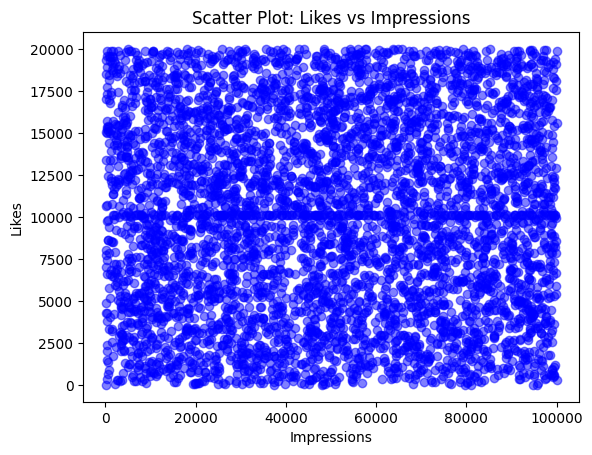

In [114]:
#Scatter Plot — Likes vs Impressions
import matplotlib.pyplot as plt

plt.scatter(df['impression_count'], df['likes'], alpha=0.5, color='blue')
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Scatter Plot: Likes vs Impressions")
plt.show()


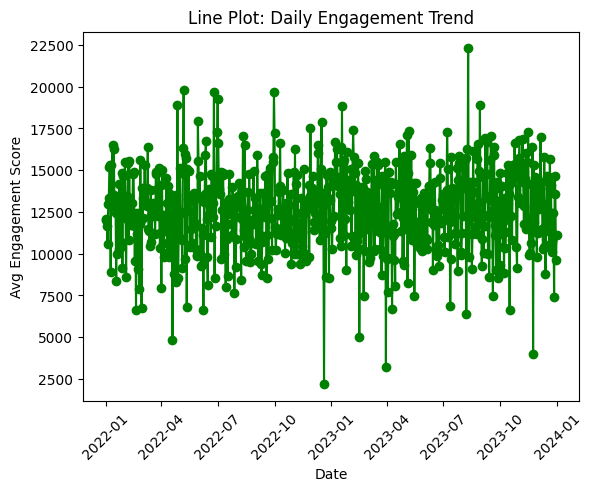

In [115]:
#Line Plot — Daily Engagement Trend
daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_score'].mean()

plt.plot(daily_engagement.index, daily_engagement.values, marker='o', color='green')
plt.xlabel("Date")
plt.ylabel("Avg Engagement Score")
plt.title("Line Plot: Daily Engagement Trend")
plt.xticks(rotation=45)
plt.show()


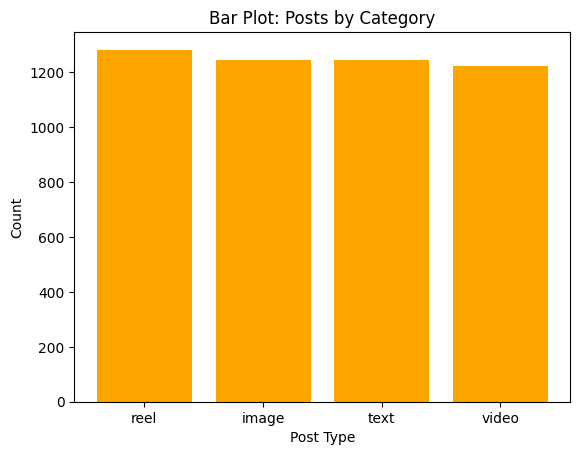

In [116]:
#Bar Plot — Posts by Category
category_counts = df['post_type'].value_counts()

plt.bar(category_counts.index, category_counts.values, color='orange')
plt.xlabel("Post Type")
plt.ylabel("Count")
plt.title("Bar Plot: Posts by Category")
plt.show()


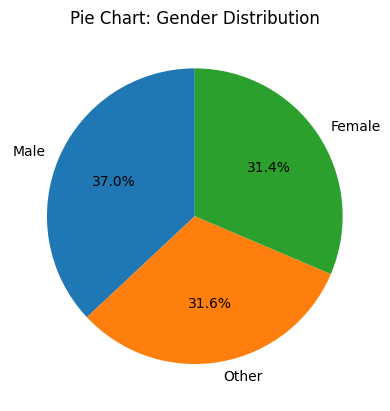

In [117]:
#Pie Chart — Gender Distribution
gender_counts = df['gender'].value_counts()

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Pie Chart: Gender Distribution")
plt.show()


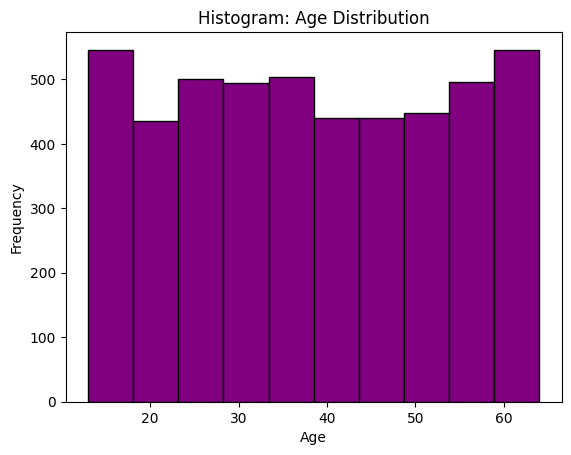

In [118]:
#Histogram — Age
plt.hist(df['age'], bins=10, color='purple', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram: Age Distribution")
plt.show()


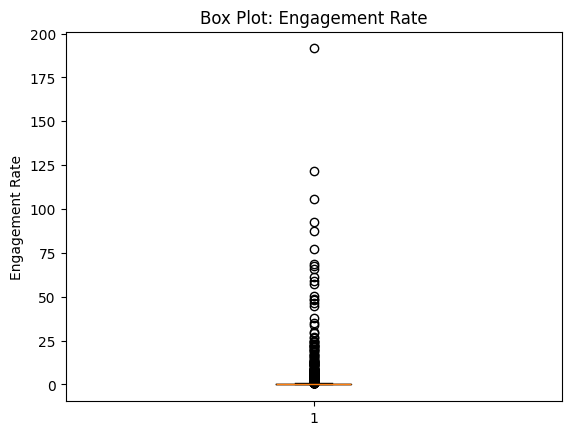

In [119]:
#Box Plot — Engagement Rate
plt.boxplot(df['engagement_rate'].dropna())
plt.ylabel("Engagement Rate")
plt.title("Box Plot: Engagement Rate")
plt.show()


Seaborn
1.Count plot: post type
2.Bar plot: avg likes by category
3.Violin: followers vs sentiment
4.Pair plot: numeric features
5.Heatmap: correlation matrix
6.Swarm plot: engagement vs device


/tmp/ipykernel_632/2275961823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='post_type', data=df, palette='Set2')


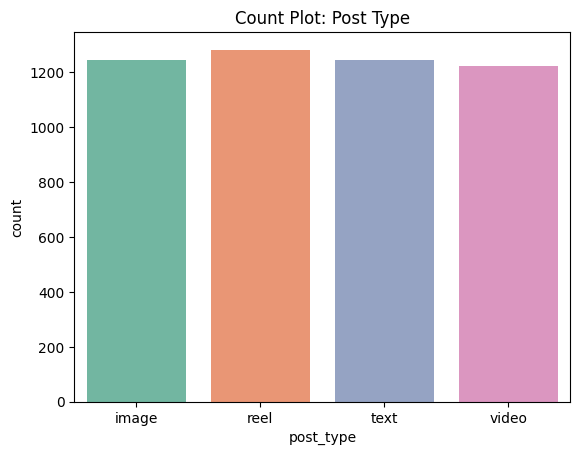

In [120]:
#Count Plot — Post Type
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='post_type', data=df, palette='Set2')
plt.title("Count Plot: Post Type")
plt.show()


/tmp/ipykernel_632/640272290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='post_type', y='likes', data=df, estimator='mean', palette='Blues')


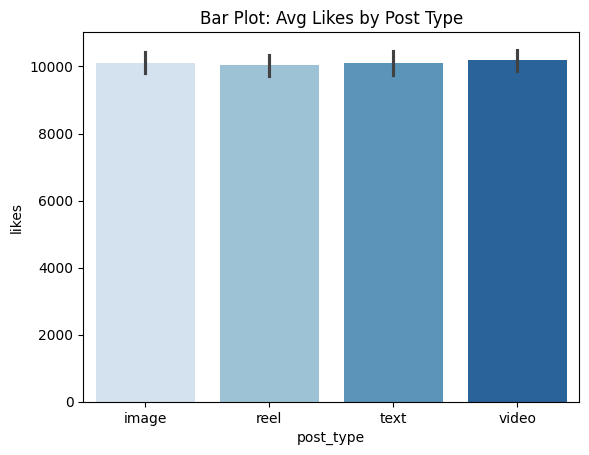

In [121]:
#Bar Plot — Avg Likes by Category
sns.barplot(x='post_type', y='likes', data=df, estimator='mean', palette='Blues')
plt.title("Bar Plot: Avg Likes by Post Type")
plt.show()


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_likes', 'log_comments',
       'log_shares'],
      dtype='object')


/tmp/ipykernel_632/361046349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sentiment', y='engagement_score', data=df, palette='muted')


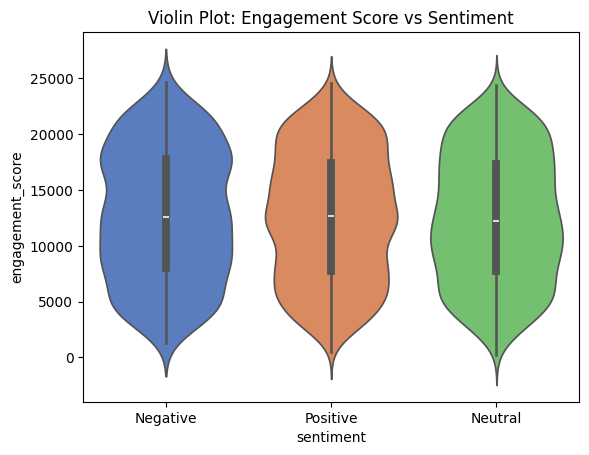

In [124]:
#Violin Plot — Followers vs Sentiment
print(df.columns)

sns.violinplot(x='sentiment', y='engagement_score', data=df, palette='muted')
plt.title("Violin Plot: Engagement Score vs Sentiment")
plt.show()




In [126]:
print(df.columns)


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_likes', 'log_comments',
       'log_shares'],
      dtype='object')


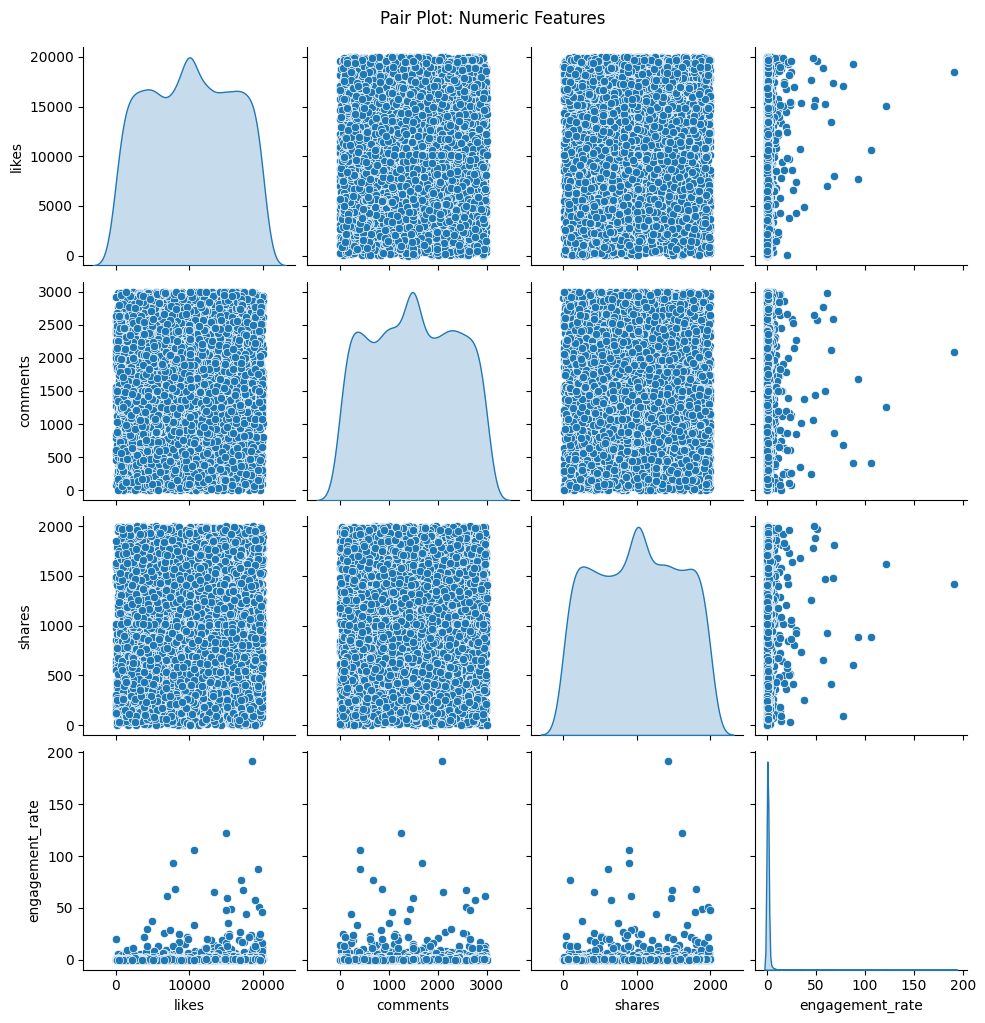

In [129]:
sns.pairplot(df[['likes','comments','shares','engagement_rate']], diag_kind='kde')
plt.suptitle("Pair Plot: Numeric Features", y=1.02)
plt.show()


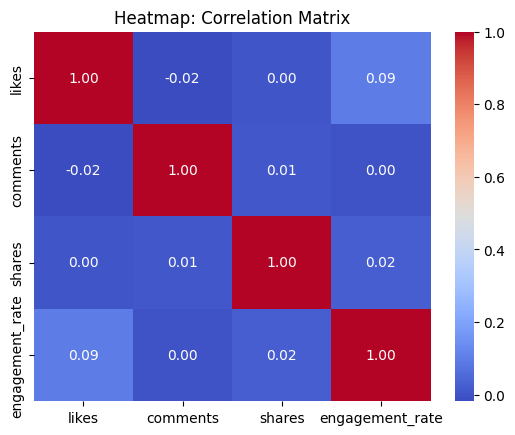

In [130]:
#Heatmap — Correlation Matrix
corr_matrix = df[['likes','comments','shares','engagement_rate']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap: Correlation Matrix")
plt.show()


/tmp/ipykernel_632/100414880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='device_type', y='engagement_score', data=df, palette='Set1')
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages

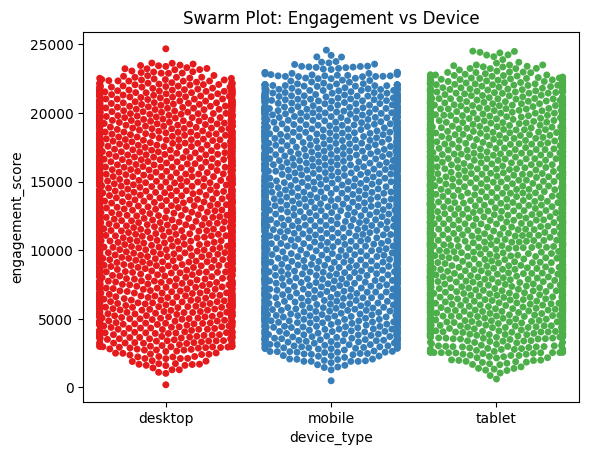

In [131]:
#Swarm Plot — Engagement vs Device
sns.swarmplot(x='device_type', y='engagement_score', data=df, palette='Set1')
plt.title("Swarm Plot: Engagement vs Device")
plt.show()


Plotly (Interactive)
Interactive line chart/bar chart/bubble/scatter chart



In [132]:
#Interactive Line Chart — Daily Engagement Trend
import plotly.express as px

daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_score'].mean().reset_index()

fig = px.line(daily_engagement, x='posted_at', y='engagement_score',
              markers=True, title="Interactive Line Chart: Daily Engagement Trend")
fig.show()


In [133]:
#Interactive Bar Chart — Posts by Category
category_counts = df['post_type'].value_counts().reset_index()
category_counts.columns = ['post_type','count']

fig = px.bar(category_counts, x='post_type', y='count',
             color='post_type', title="Interactive Bar Chart: Posts by Category")
fig.show()


In [134]:
#Interactive Bubble Chart — Likes vs Comments
fig = px.scatter(df, x='likes', y='comments',
                 size='shares', color='post_type',
                 hover_data=['engagement_score'],
                 title="Interactive Bubble Chart: Likes vs Comments (Bubble = Shares)")
fig.show()


In [135]:
#Interactive Scatter Chart — Impressions vs Engagement
fig = px.scatter(df, x='impression_count', y='engagement_score',
                 color='device_type', hover_data=['likes','comments','shares'],
                 title="Interactive Scatter Chart: Impressions vs Engagement")
fig.show()


#**Final Insights should Include following analysis
Content Performance



In [136]:
#Which Post Types Have Highest Engagement?
summary_post_type = df.groupby('post_type')['engagement_score'].mean().sort_values(ascending=False)
print(summary_post_type)

#👉 Reveals the highest engagement post types (e.g., reels > videos > images).

#Short-form video content often dominates engagement.

#Static posts may lag behind interactive formats.

post_type
video    12664.594286
image    12649.390537
text     12613.243775
reel     12524.031567
Name: engagement_score, dtype: float64


/tmp/ipykernel_632/2782721691.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [138]:
#Best-Performing Content Category
if 'category' in df.columns:
    summary_category = df.groupby('category')['engagement_score'].mean().sort_values(ascending=False)
    print(summary_category)
else:
    print("No 'category' column found — consider using post_type or topic instead.")


No 'category' column found — consider using post_type or topic instead.


In [139]:
summary_country = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)
print(summary_country)


country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


/tmp/ipykernel_632/2533151971.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [140]:
#Which Countries Have Highest Avg Engagement Rate?

summary_country = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)
print(summary_country)


country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


/tmp/ipykernel_632/3729155371.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#**User Trends
How age affects engagement
Performance difference for verified accounts



In [141]:
#Age vs Engagement
# Group by age buckets (e.g., 18–24, 25–34, etc.)
df['age_group'] = pd.cut(df['age'], bins=[0,18,25,35,45,60,100],
                         labels=['<18','18-24','25-34','35-44','45-60','60+'])

age_engagement = df.groupby('age_group')['engagement_score'].mean().sort_values(ascending=False)
print(age_engagement)


age_group
<18      12991.711538
25-34    12768.703874
35-44    12673.039957
18-24    12628.408385
60+      12326.388889
45-60    12318.709538
Name: engagement_score, dtype: float64


/tmp/ipykernel_632/1275425241.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [142]:
#Verified vs Non-Verified Accounts
# Assuming 'is_verified' column exists (True/False)
verified_perf = df.groupby('is_verified')['engagement_score'].mean()
print(verified_perf)


is_verified
False    12644.311822
True     12309.280538
Name: engagement_score, dtype: float64


/tmp/ipykernel_632/3553731654.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**Behavioral Insights
Best time of day for impressions


Device type impact on watch time**

In [ ]:
#Best Time of Day for Impressions
# Convert posted_at to hour of day
df['hour'] = df['posted_at'].dt.hour

# Group by hour and compute average impressions
hourly_impressions = df.groupby('hour')['impression_count'].mean().sort_values(ascending=False)
print(hourly_impressions)


In [ ]:
#Device Type Impact on Watch Time
# Group by device type and compute average watch time
device_watch_time = df.groupby('device_type')['watch_time'].mean().sort_values(ascending=False)
print(device_watch_time)


**Sentiment Analysis**


Which sentiment performs best


Behavior of negative/neutral sentiment posts


In [147]:
#Which Sentiment Performs Best
if 'sentiment' in df.columns:
    sentiment_perf = df.groupby('sentiment')['engagement_score'].mean().sort_values(ascending=False)
    print(sentiment_perf)
else:
    print("No 'sentiment' column found — consider adding or deriving sentiment labels first.")


sentiment
Negative    12731.498958
Positive    12665.799443
Neutral     12448.163720
Name: engagement_score, dtype: float64


In [149]:
#Behavior of Negative/Neutral Sentiment Posts
# Analyze negative and neutral posts
if 'sentiment' in df.columns:
    neg_neu_perf = (
        df[df['sentiment'].isin(['Negative','Neutral'])]
          .groupby('sentiment')[['likes','comments','shares','engagement_score']]
          .mean()
    )
    print(neg_neu_perf)
else:
    print("No 'sentiment' column found — cannot analyze negative/neutral behavior.")


                  likes     comments       shares  engagement_score
sentiment                                                          
Negative   10208.096875  1516.094792  1007.307292      12731.498958
Neutral     9923.194499  1528.404060   996.565160      12448.163720
